# AP 155 Lab Exercise
---
## Exercise 1: Idiomatic Python

_Instructions_: 
- **Report figure (Problem 1):** Plot the 2D wave interference pattern between 2 (or more) coherent sources. Include at least 1 figure.
- **Report discussion (Problem 2):** Write a custom `matrix_multiply()`function using Python list comprehensions without external libraries (do not use `np.dot()` or `@`).
    - (i) For larger matrices, which is preferred, the custom `matrix_multiply()` or the `@` operator... why?
    - (ii) What are the general benefits of writing idiomatic Python?
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Sinadjan, Joseph Daniel
- _Student No._: 2024-13266
- _Section_: THU-WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Problem 1 

![Wave interferance simulator for two particles producing ripples on a surface](waves.png)

The above figure is the wave interference pattern for two objects dropped onto some surface, making ripples.

### Problem 2 

Implementation of the random matrix generator, scalar product, matrix transpose, and matrix multiplication complete with compalibility and empty entry checker is discussed in great detail in Section 2, with relevant commentary. Needless to say, the code works. Sample demos are included in each cell, and I also did a few edge case tests (though not exhaustive in the slightest).

### Other comments
- On my LIFE I didnt use any AI for this, not even a little bit. AI is cringe, and using AI for a class where you are supposed to LEARN is even more cringe
- Formatting and aesthetics are not my forte, and my matrices in list-of-lists form dont really look a lot like matrices


---
## Section 2: Code

### Problem 1: 2D Wave interference (Gezerlis Problem 1.15)

Assume that the combined eﬀect of two objects dropped in a water basin can be modelled by:
$$ W(\textbf{r}) = A \sin (k|\textbf{r}-\textbf{r}_0|) + A  \sin (k|\textbf{r}-\textbf{r}_1|). $$ You can think of this as an updated version of Eq. (1.3) in the book, where we are dealing with the linear addition of sinusoidal waves, instead of electric-field contributions. For simplicity, take $A=1$, $k=2\pi/0.3$, $r_0 = (−1, 0)$ , and $r_1 = (1, 0)$. Since we are now faced with a density plot, you should employ, NOT `streamplot()` but, `imshow()` from `Matplotlib`; in each of $x$ and $y$ your plot should extend from $−4$ to $+4$.

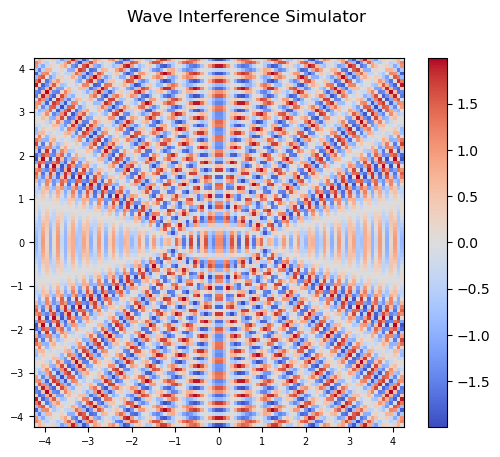

In [55]:
"""
strategy

We are given a function in terms of position as vector quantities, and then asked to get the vectors' magnitudes.
Firstly, we want to translate the problem from working with vectors to working with scalars. Then, we implement the
function. Lastly we can worry about aesthetics and presentation.

"""

import matplotlib.pyplot as plt
import numpy as np

# Define our xy-axes
x_axis = np.linspace(-4, 4, 100)
y_axis = np.linspace(-4, 4, 100)

# We want to take advantage of np.array properties, so we make a matrix
y_axis_matrix = y_axis.reshape(-1, 1)

# Formatting y_axis as a -1x1 matrix is an easy way to add a second dimension to the plot
# Functions acting on x_axis and y_axis_matrix automatically return a 2D array 


# Here are variables used in succeeding functions

const_A = 1
const_k = 2*np.pi/0.3
vector_r0_x = -1
vector_r0_y = 0
vector_r1_x = 1
vector_r1_y = 0


# Finally we implement the function 
# We are explicitly translating from vector quantities to vector components in Cartesian coords. Luckily only the vector
# magnitude matters here so we can get away with this. This approach will NOT translate for other vector quantities.

def wave_interference_simulator(x_axis, y_axis, vector_r0_x, vector_r0_y, vector_r1_x, vector_r1_y, const_A, const_k):
    function_wave_one = const_A*np.sin(const_k*np.sqrt((x_axis - vector_r0_x)**2 + (y_axis_matrix - vector_r0_y)**2))
    function_wave_two = const_A*np.sin(const_k*np.sqrt((x_axis - vector_r1_x)**2 + (y_axis_matrix - vector_r1_y)**2))
    function_display = function_wave_one + function_wave_two

    fig, ax = plt.subplots()
    fig.suptitle("Wave Interference Simulator")
    n = ax.imshow(function_display, extent=(-4.25,4.25,-4.25,4.25), cmap="coolwarm")
    ax.tick_params(axis="both", labelsize="7")
    fig.colorbar(n)

    plt.savefig('waves.png')
    plt.show()

# And we call it

wave_interference_simulator(x_axis, y_axis, vector_r0_x, vector_r0_y, vector_r1_x, vector_r1_y, const_A, const_k)

# Et voila!




#### Problem 1 code summary

Here, the fact that only the vector magnitude |r-r_0| was relevant to the problem was key to translating the equation into easy to implement functions on scalars. The hard part of the problem was the fine-tuning of the plot and all the bells and whistles that come with python's plotting libraries; graphic design is NOT why i chose to do physics.

---

### Problem 2: Listcomps-maxxing

Import the `random` library (docs: https://docs.python.org/3/library/random.html). We will be using the `random.randint` function to pick random integers.

In [13]:
import random
number = random.randint(1, 9)
number

5

a. Create a function `random_integer_matrix(nrows, ncols)` that generates a matrix in the form of "list-of-lists" whose elements are random integers from $1$ to $9$. Each "sub-list" inside the main list is a row in the matrix.

In [14]:
"""
strategy:

we need to create a matrix in list-of-lists form, where the sublists are the rows; the number of elements in each sublist
is the number of columns, the number of sublists is the number of rows. Perhaps .append is useful here?

"""

import random

def random_integer_matrix(nrows, ncols):
    
    # We need some way to 'store' data in between loop iterations. What I did here was to define w and z as dummy variables,
    # in this case as empty lists. Each loop then appends the random integer to the dummy variable before beginning the next
    # iteration. Since the variable values are not affected by the loop process except for when we specifically code the loop
    # to change the values of the varaibles, this serves as a sort of memory for our function. Going forward, this approach of
    # using dummy variables to store values outside of control loops may become more important.
    
    w = [] # List of lists dummy variable
    z = [] # sublist dummy variable

    # Loop that defines the number of sublists created; defines the number of rows.
    for i in range(nrows):
        
        # Loop that defines the number of elements in each sublist; defines the number of columns.
        for j in range (ncols):
            a = random.randint(1,9)
            z.append(a)  
        w.append(z)

        # This line is VERY important. The value of any variable is not affected by loops unless we define that behavior in
        # the loop itself. In previous iterations of this function, I neglected to add this line. The result was that for each
        # iteration of the outer nrows loop, z was retaining the values of previous loops. The second sublist was 8 elements
        # long instead of 4, and the third was 12. This line 'empties' the z "container", making it ready to accept the new 
        # values for the next sublist. This type of behavior will appear in variables used as indexes as well.
        z = []
          
    return w

random_integer_matrix(3, 4) # call the function to create a 3x4 matrix

[[7, 7, 3, 2], [4, 1, 9, 3], [9, 3, 9, 4]]

b. Create a function `scalar_product(list1, list2)` where you multiply each element at the same index in the two lists and sum/accumulate the results.

In [15]:
"""
strategy

we need to assign indices to each element in the list, multiply only elements with the same index, and sum 
all together. last time dummy variables worked well as data containers, maybe they will come in handy again.

"""
mylist1 = [1,2,3,4,5]
mylist2 = [9,8,7,6,5]

def scalar_product(list1, list2):  

    # Again, we use the dummy varaible approach 
    
    i_index = 0
    j_index = 0
    x=0               # Scalar value product dummy variable

    if len(list1) == len(list2):  # compatibility check
        for i in list1:
            
            i_index +=1
    
            # Resets the j_index so that it does not grow for each outer loop iteration
            j_index = 0
            
            for j in list2:
                
                j_index +=1
                
                if i_index == j_index:
                
                    x +=(i*j)

    else:
        x = ("Vectors are incompatible!")

    return x

#I could have probably used .zip to make the implementation less index-y, but it works so it is what it is ig

# testing
mylist1 = [1,2,3,4,5]
mylist2 = [9,8,7,6,5]

print(scalar_product(mylist1, mylist2))

incompatible_list = [1,2,3]

print(scalar_product(mylist1, incompatible_list))

95
Vectors are incompatible!


c. Create a function `transpose_matrix(orig_matrix)` which returns the transpose of any matrix also in "list-of-lists" form. Do not assume the size of the matrix; figure it out within the function. Double-check that your implementations above work. Create a $3\times4$ random integer matrix, print it out and its transpose. The values and shape between the two should be consistent.

In [16]:
def transpose_matrix(mymatrix):

    # This block checks if a matrix has valid dimensions
    length = len(mymatrix[0])
    flag = True
    
    for i in range(len(mymatrix)):
        
        if len(mymatrix[i]) == length:
            flag = True
        
        else:
            flag = False
            break

    # Defining our dummy variables
    x = []
    y = []

    # This block executes the matrix transpose
    if flag == True:
        
        for i in range(len(mymatrix[0])):
            
            for j in mymatrix:
                
                y.append(j[i])
       
            x.append(y)
            y = []
    else:
        x =("Matrix Invalid!")
    return x

random_matrix = random_integer_matrix(3, 4)
false_matrix = [[1,2,3],[3,4,5,6,7],[5,6,7]]

print(random_matrix)
print(transpose_matrix(random_matrix))
print(transpose_matrix(false_matrix))

[[4, 4, 7, 1], [1, 9, 6, 1], [3, 4, 9, 6]]
[[4, 1, 3], [4, 9, 4], [7, 6, 9], [1, 1, 6]]
Matrix Invalid!


d. Create a function `matrix_multiply(left_matrix, right_matrix)` which performs the matrix multiplication. Do not assume the matrices follow a specific shape. Here's some tips and strategies:
* Determine how many rows and columns the left and right matrices have. Which numbers should match in order for us to have valid matrix multiplication?
* Iterating the elements of "list-of-lists" gives us the rows, but we need to iterate the columns for the right matrix.
* Use the `transpose_matrix` function, then iteratively apply `scalar_product`.

In [41]:
#matrix multiply


def matrix_multiply(left_matrix, right_matrix):

    
# check the dimensional consistency of each matrix

    left_length = max(len(left_matrix[i]) for i in range(len(left_matrix)))
    right_length = max(len(right_matrix[j]) for j in range(len(right_matrix)))
    
    left_flag = True
    right_flag = True
    
    for i in range(len(left_matrix)):
        
        if len(left_matrix[i]) == left_length:
            left_flag = True
        
        else:
            left_flag = False
            break

    for j in range(len(right_matrix)):
        
        if len(right_matrix[j]) == right_length:
            right_flag = True
        
        else:
            right_flag = False
            break

# check for dimensional compatibility

    compatible_flag = True
    
    
    if len(left_matrix[0]) == len(right_matrix):
        compatible_flag = True

    else:
        compatible_flag = False
    
# master check

    master_flag = True
    
    if right_flag == True:
        pass
    else:
        master_flag = False

    if left_flag == True:
        pass
    else:
        master_flag = False

    if compatible_flag == True:
        pass
    else:
        master_flag = False
    



#implement repeated scalar multiplication

    
    #dummy variables

    container_a =[] #sublist container
    container_b =[] # list-of-lists container
    
    m_left_matrix = left_matrix                      # form the matrix takes as manipulated by the final algorithm
    m_right_matrix = transpose_matrix(right_matrix)  # form the matrix takes as manipulated by the final algorithm
    
    
#algorithm
    
    if master_flag == True:
        for i in m_left_matrix:
                    
            for j in m_right_matrix:
                        
                
                p = scalar_product(i,j)
                container_a.append(p)
                
            container_b.append(container_a)
            container_a = []
    else:
        container_b = ("Something's wrong!")
             

        
#    print(master_flag)    # , for debugging

    return container_b


# testing

left_matrix = random_integer_matrix(3,4)
right_matrix = random_integer_matrix(4,5)

print(left_matrix)
print(right_matrix)

print("compatible matrices,",matrix_multiply(left_matrix,right_matrix))


left_false_matrix = [[1,2],[3,4,2],[6,7]]
right_false_matrix = [[2,1,4],[5,1]]

print("false matrices,", matrix_multiply(left_false_matrix, right_false_matrix))

left_incompatible_matrix = [[1,2,3,4],[5,6,7,8],[9,0,1,2]] # 3x4
right_incompatible_matrix = [[1,2,3],[4,5,6]]              # 2x3

print("incompatible matrices,", matrix_multiply(left_incompatible_matrix, right_incompatible_matrix))

[[1, 8, 8, 1], [5, 7, 4, 7], [9, 3, 4, 4]]
[[4, 7, 5, 7, 8], [8, 4, 9, 2, 5], [3, 7, 9, 2, 9], [5, 9, 3, 9, 6]]
compatible matrices, [[97, 104, 152, 48, 126], [123, 154, 145, 120, 153], [92, 139, 120, 113, 147]]
false matrices, Something's wrong!
incompatible matrices, Something's wrong!


#### Problem 2 code summary

The algorithm performs matrix multiplication (although not particularly elegantly) by implementing pythonic features such as list comprehension, list-of-lists data types, and (what I believe is my most creative workaround in the activity) the use of dummy variables as indices and containers to implement 'memory-like' behavior. I also took the time to implement checks for matrix-multiply dimension compatibility and checks to ensure that matrices had no missing entries, though the repeated compatibility checks probably slow down code exectuion by a fair margin. 

---
## Section 3: Background

### Basics

In [18]:
x = 0.5 # floats
y = 1 # integer
z = 'Hello' # string

x, y = y, x # swapping variables
a, b = 2, 3 # multiple assignments
print(x)
print(y)

1
0.5


In [19]:
x + y # sum
x - y # difference
x * y # multiplication
x / y # division
x // y # floor division
x % y # modulo
x ** y # power

1.0

### Control flow

In [20]:
x = 0

if x!= 0:
    print("x is nonzero")
elif x==0:
    print("x is zero")

x is zero


In [21]:
y = 25
if (y%5==0) == True:
    print('y is divisible by 5')

y is divisible by 5


In [22]:
# you can write truthiness conditionals more succinctly as 
# if condition is True, mathematically a True equals 1.0 while a False equals 0.0
if not (y%5):
    print('y is divisible by 5')

y is divisible by 5


In [23]:
for i in range(1,15,2):
    print(0.01*i, end=" ") # the end=" " syntax tells the value shall be printed in line

0.01 0.03 0.05 0.07 0.09 0.11 0.13 

### Data structures

In [24]:
xs = []
for i in range(20):
    xs.append(0.1*i)

# BE CAREFUL!!!
# list is different from array
list1 = [1, 2, 3]
list2 = [4, 5, 6]
list1 + list2 # concatenates

[1, 2, 3, 4, 5, 6]

In [25]:
list1 = np.array([1, 2, 3])
list2 = np.array([4, 5, 6])
list1 + list2 # adds element-wise!

array([5, 7, 9])

In [26]:
# Tuples are primarily used to bundle related pieces of data together, 
# protect data from accidental modification, and optimize performance.

tuple1 = (1, 2, 3)
tuple1[1]  # can be indexed just like lists

2

In [27]:
# strings can also be indexed like numbers

name = "Wilson"
name[0]

'W'

In [28]:
# string dot format arguments

x, y = 3.1, - 2.5
"{0:1.15f} {1:1.0f}".format(x, y) 

# the general string format looks like "{2} {0} {1}".format(a, b, c)
# the number inside the curly brackets contain the index of the variables inside the format( ... )
# you can modify the numbers outputted by specifiying the datatype inside the curly bracket 
# {0:1.15f} means print the zeroth number and print the number as a float with 15 decimal places 
# {1: 1.0f} means print the 1st number (second actually) and print as a float with 0 decimal places

'3.100000000000000 -2'

In [29]:
# slicing a list creates a new list

xs = [1, 2, 3]
ys = xs[1:] # the square bracket after a list corresponds to index (start:end) ... (start:end:interval)
zs = xs[:] # [:] means copy everything --> create an exact (shallow) copy of xs
print(xs)
print(ys)

# shallow copy duplicates an object's top-level properties 
# but keeps references to any nested objects, meaning changes to nested data affect the original. 
# A deep copy fully clones all levels and nested structures,
# creating a completely independent duplicate where changes do not affect the original.

[1, 2, 3]
[2, 3]


In [30]:
import copy
from copy import deepcopy

original = [1, 2, [3, 4]] # notice the list inside a list
shallow_copied = original[:]

# modifying a top-level element
shallow_copied[0] = 99
print("After modifying top-level element:")
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

# modifying a nested mutable element
shallow_copied[2][0] = "changed" 
print("\nAfter modifying nested element (SHALLOW):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

deep_copied = deepcopy(original)
original = [1, 2, [3, 4]]
deep_copied[2][0] = "changed" 
print("\nAfter modifying nested element (DEEP COPIED):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {deep_copied}")  

After modifying top-level element:
Original: [1, 2, [3, 4]]
Copied:   [99, 2, [3, 4]]

After modifying nested element (SHALLOW):
Original: [1, 2, ['changed', 4]]
Copied:   [99, 2, ['changed', 4]]

After modifying nested element (DEEP COPIED):
Original: [1, 2, [3, 4]]
Copied:   [1, 2, ['changed', 4]]


In [31]:
# dictionaries

htow = {1.41: 31.3, 1.45: 36.7, 1.48: 42.4} # is a dictionary associating heights to weights
# each entry is separated by a comma,
# each entry is composed of keys and items
# the first key is 1.41 with corresponding 31.3 item

for key, item in htow.items():
    print(f'key is {key} with item {item}')

# dictionaries are pretty useful for collecting a parallel set of content
# you can use strings as keys too

key is 1.41 with item 31.3
key is 1.45 with item 36.7
key is 1.48 with item 42.4


### User-defined functions

In [32]:
# start with def<space>name_of_your_function(input, parameters):
# end with return
# once a function encounters return, it ends all operations and sends the value back to the caller

def sumofints(nmax):
    val = sum(range(1,nmax+1))
    return val

# use the above function as
x = sumofints(42)
print(x)

# you could have multiple inputs and outputs
# functions can also return multiple values (effectively the output is a tuple for such cases)

903


In [33]:
from math import cos

def cosder(x, h=0.01): # here h is a default parameter (meaning it already has a preset value)
    return (cos(x+h) - cos(x))/h

#You can call this function with either 
cosder(0.)
#or 
cosder(0., 0.001)
#ie the 2nd argument is optional

-0.0004999999583255033

In [34]:
# you can also pass functions as inputs
def der(f, x, h=0.01):
    return (f(x+h) - f(x))/h

### List comprehensions
"Using such alternative syntax to make the code more concise and ex-
pressive helps us write new programs, but also makes the lives of future readers easier. Of
course, you do have to exercise your judgement."

In [35]:
def f(x):
    return x//2

xs = [0.1*i for i in range(20)] 
ys = [2*x for x in xs] # multiplication operation with a list
ws = [f(x) for x in xs] # evaluating a function with elements of a list
zs = [2*x for x in xs if x>0.3] # pruning a list

### Basic plotting

- We will utilize NumPy and Matplotlib for most of our visualization
    - `import numpy as np` # Docs: https://numpy.org/doc/stable/reference/
    - `import matplotlib.pyplot as plt` # Docs: https://matplotlib.org/stable/api/pyplot_summary.html
  
- We will use Seaborn only to make the defaults look pretty.
- Our focus is to make plotting as flexible as possible.
- Check out its documentation if you're interested with its convenience features.
    - `import seaborn as sns` # Guide: https://seaborn.pydata.org/tutorial/introduction.html
    `sns.set_theme(style="darkgrid")`

<img src="figures/gezerlisTable1_1.png" width="67%">

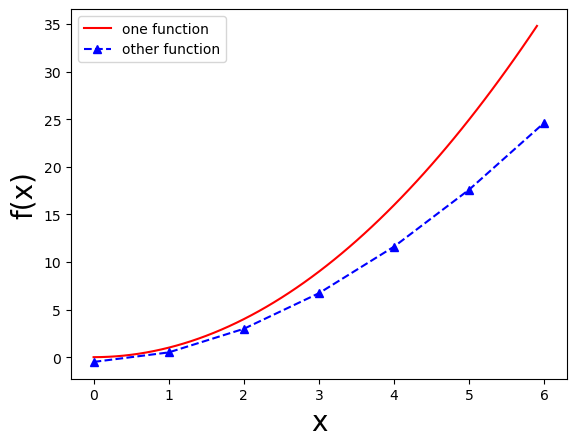

In [36]:
import matplotlib.pyplot as plt

def plotex(cxs,cys,dxs,dys):
    plt.xlabel('x', fontsize=20)
    plt.ylabel('f(x)', fontsize=20)
    plt.plot(cxs, cys, 'r-', label='one function')
    plt.plot(dxs, dys, 'b--^', label='other function')
    plt.legend()
    plt.show()

cxs = [0.1*i for i in range(60)]
cys = [x**2 for x in cxs]
dxs = [i for i in range(7)]
dys = [x**1.8 - 0.5 for x in dxs]

plotex(cxs, cys, dxs, dys)

<ErrorbarContainer object of 3 artists>

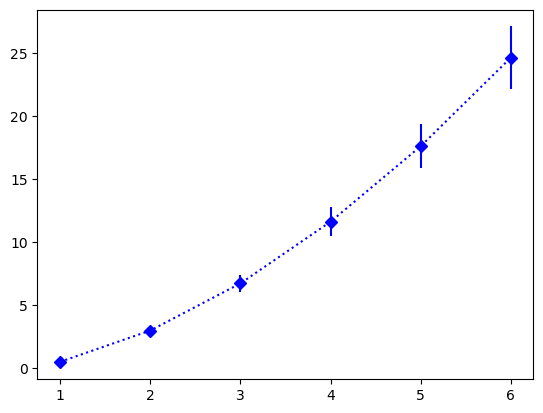

In [37]:
dyerrs = [0.1*y for y in dys]
plt.errorbar(dxs[1:], dys[1:], dyerrs[1:], fmt='b:D', label='with errors')

### NumPy idioms

<img src="figures/gezerlisTable1_2.png" width="67%">

In [38]:
import numpy as np

# for parallel computations: contribs = [w*f(x) for w,x in zip(ws,xs)]

zs = np.array([5, 8], dtype=np.float32) # converts contribs into a NumPy array
A, B, C = np.zeros(5), np.ones(4), np.arange(6)

print(A)
print(B)
print(C)

[0. 0. 0. 0. 0.]
[1. 1. 1. 1.]
[0 1 2 3 4 5]


In [39]:
# you can specify set of points

np.linspace(1, 10, 6) # 6 linearly spaced points from 1 to 10 (including 1 and 10)
np.arange(1, 10, 6) # from 1 to 10 in steps of 6
np.logspace(1, 10, 6) # 6 logarithmically spaced points from 1 to 10

# if you're not sure what to input, you can always shift+Tab inside the parenthesis to check the arguments

array([1.00000000e+01, 6.30957344e+02, 3.98107171e+04, 2.51188643e+06,
       1.58489319e+08, 1.00000000e+10])

<img src="figures/gezerlisTable1_3.png" width="67%">

<img src="figures/gezerlis_slicingArrays.png" width="67%">

### Visualizing Electric Fields 

The electric field anywhere given a set of $n$ point charges is given by
$$ \mathbf{E}(\mathbf{r}) = \sum_{i=0}^{n-1} kq_i \frac{\mathbf{r} - \mathbf{r}_i}{|\mathbf{r} - \mathbf{r}_i|^3} $$

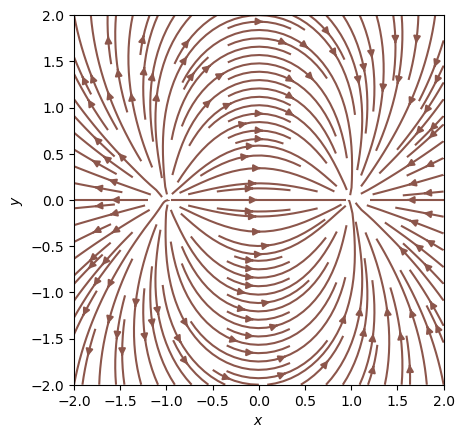

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from copy import deepcopy

def makefield(xs, ys):
    qtopos = {1: (-1,0), -1: (1,0)}
    n = len(xs)
    Exs = [[0. for k in range(n)] for j in range(n)]
    Eys = deepcopy(Exs)
    for j,x in enumerate(xs):
        for k,y in enumerate(ys):
            for q, pos in qtopos.items():
                posx, posy  = pos
                R = sqrt((x - posx)**2 + (y - posy)**2)
                Exs[k][j] += q*(x - posx)/R**3
                Eys[k][j] += q*(y - posy)/R**3
    return Exs, Eys

def plotfield(boxl,n):
    xs = [-boxl + i*2*boxl/(n-1) for i in range(n)]
    ys = xs[:]
    Exs, Eys = makefield(xs, ys)
    xs=np.array(xs); ys=np.array(ys)
    Exs=np.array(Exs); Eys=np.array(Eys)
    plt.streamplot(xs, ys, Exs, Eys, density=1.5, color='tab:brown')
    plt.xlabel('$x$')
    plt.ylabel('$y$')
    plt.axis('square')
    plt.show()
    
plotfield(2., 50)

FileNotFoundError: [Errno 2] No such file or directory: 'figures/sample.png'

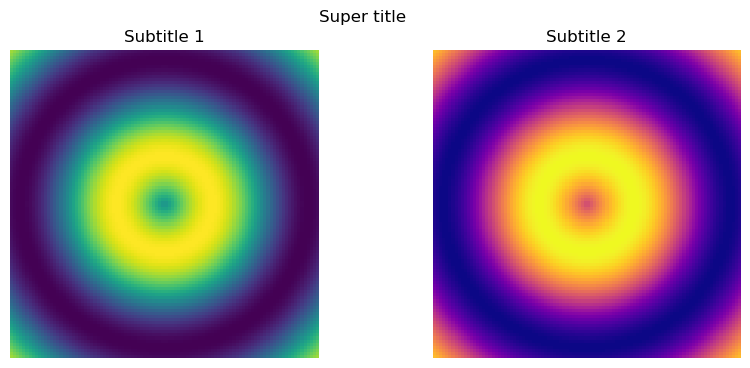

In [41]:
# sample plotting in notebook and putting saved image in another cell (see Report figure)

import matplotlib.pyplot as plt
import numpy as np

# sample grid and data
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z1 = np.sin(np.sqrt(X**2 + Y**2))        

# create subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# plot on first axs (left)
axs[0].imshow(Z1, cmap='viridis')
axs[0].set_title("Subtitle 1")
axs[0].axis('off')

# plot on the second axis (right)
axs[1].imshow(Z1, cmap='plasma')
axs[1].set_title("Subtitle 2")
axs[1].axis('off')

fig.suptitle("Super title")

# save image locally without rendering in the notebook
plt.savefig('figures/sample.png', bbox_inches='tight', dpi=150)
plt.close()